### Correlating voxels and parcels 

In [1]:
#### IMPORTING MODULES ####
import os
os.chdir("/home/anna-beer/Documents/anna_phd/Canonical-HMM-Networks") #sets working directory to the repo, so that all imports work correctly
print(os.getcwd())
import numpy as np
from pathlib import Path
import scipy
import matplotlib.pyplot as plt
import mne
mne.viz.set_3d_backend("notebook")
from osl_dynamics.analysis import power
from osl_dynamics.utils import plotting
from osl_dynamics.meeg import parcellation

/home/anna-beer/Documents/anna_phd/Canonical-HMM-Networks
Using notebook 3d backend.


In [2]:
def gettingpsds(parc_fif):

    raw = mne.io.read_raw_fif(parc_fif)

    fs = raw.info["sfreq"]
    parc_ts = raw.get_data(picks="misc", reject_by_annotation="omit")

    f, psd = scipy.signal.welch(parc_ts, fs=fs, nperseg=fs, nfft=fs * 2)

    return f, psd, raw

In [3]:
subjects = ["001", "002", "003", "004", "005", "006", "007", "009", "010", "011", "012", "013", "014", "015", "016"] #"002", "003", "004", "005", "006", "007", # "001", "002", "003", "004", "005", "006", "007", "009", "010", "011", "012", "013", "014", "015", "016"
sessions_opms = ["001", "002"]
sessions_squids = ["003", "004"]
tasks = ["braille"]
runs = ["001"]

freqs_opms_parc = []
psds_list_opms_parc = []
freq_squid_parc = []
psds_list_squid_parc = []
raw_parc_opms = []
raw_parc_squid = []

freqs_opms_beam = []
psds_list_opms_beam = []
freq_squid_beam = []
psds_list_squid_beam = []
raw_beam_opms = []
raw_beam_squid = []


base = "/rdrives/DRS-foundation-brain/zoe_data/BIDS"
deriv = f"{base}/derivatives_anna_01042026"

for subject in subjects:
    for session in sessions_opms:
        for task in tasks:
            for run in runs:

                id = f"sub-{subject}_ses-{session}_task-{task}_run-{run}"
                parc_fif_opms = (f"{deriv}/osl_noorthog/{id}/lcmv-parc-raw.fif")
                beam_fif_opm = (f"{deriv}/beamformed_noorthog/{id}_beamformed_raw.fif")

                f_opm, psd_opm, raw_opm = gettingpsds(parc_fif_opms)
                freqs_opms_parc.append(f_opm)
                psds_list_opms_parc.append(psd_opm)
                raw_parc_opms.append(raw_opm)

                # f_opm_beam, psd_opm_beam, raw_opm_beam = gettingpsds(beam_fif_opm)
                # freqs_opms_beam.append(f_opm_beam)
                # psds_list_opms_beam.append(psd_opm_beam)
                # raw_beam_opms.append(raw_opm_beam)

    for session in sessions_squids:
        for task in tasks:
            for run in runs:

                id = f"sub-{subject}_ses-{session}_task-{task}_run-{run}"
                parc_fif_squids = (f"{deriv}/osl_noorthog/{id}/lcmv-parc-raw.fif")
                beam_fif_squids = (f"{deriv}/beamformed_noorthog/{id}_beamformed_raw.fif")

                f_squid, psd_squid, raw_squid = gettingpsds(parc_fif_squids)
                freq_squid_parc.append(f_squid)
                psds_list_squid_parc.append(psd_squid)
                raw_parc_squid.append(raw_squid)

                # f_squid_beam, psd_squid_beam, raw_squid_beam = gettingpsds(beam_fif_squids)
                # freq_squid_beam.append(f_squid_beam)
                # psds_list_squid_beam.append(psd_squid_beam)
                # raw_beam_squid.append(raw_squid_beam)

Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/osl_noorthog/sub-001_ses-001_task-braille_run-001/lcmv-parc-raw.fif...
    Range : 31930 ... 358698 =    127.720 ...  1434.792 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/osl_noorthog/sub-001_ses-002_task-braille_run-001/lcmv-parc-raw.fif...
    Range : 35501 ... 362221 =    142.004 ...  1448.884 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/osl_noorthog/sub-001_ses-003_task-braille_run-001/lcmv-parc-raw.fif...
    Range : 17069 ... 337499 =     68.276 ...  1349.996 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/osl_noorthog/sub-001_ses-004_task-braille_run-001/lcmv-parc-raw.fif...
    Range : 2573 ... 330092 =     10.292 ...  1320.368 secs
Ready.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives

/tmp/ipykernel_13860/2598467246.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_13860/2598467246.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


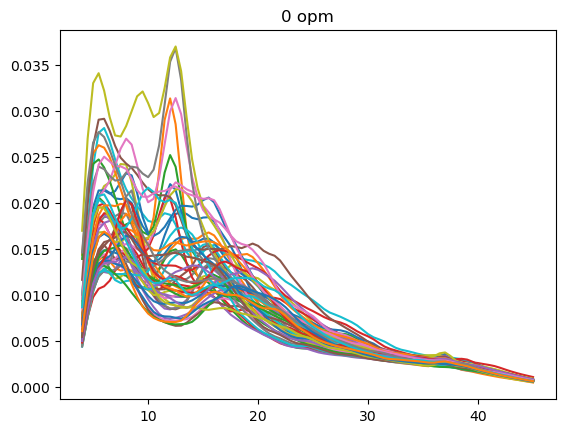

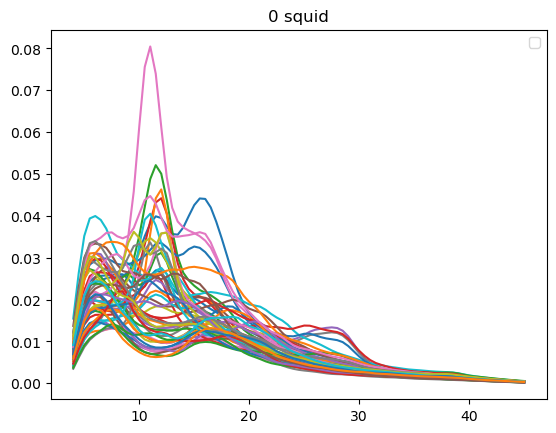

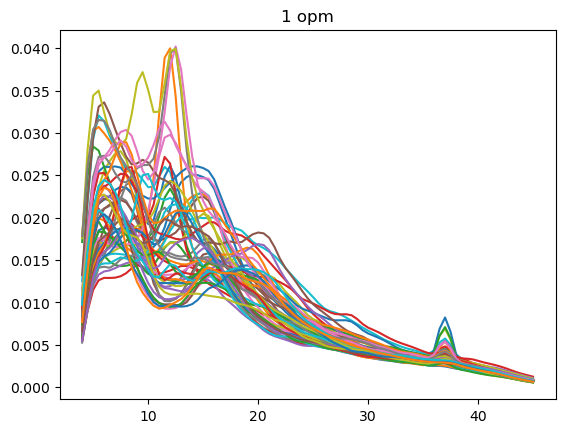

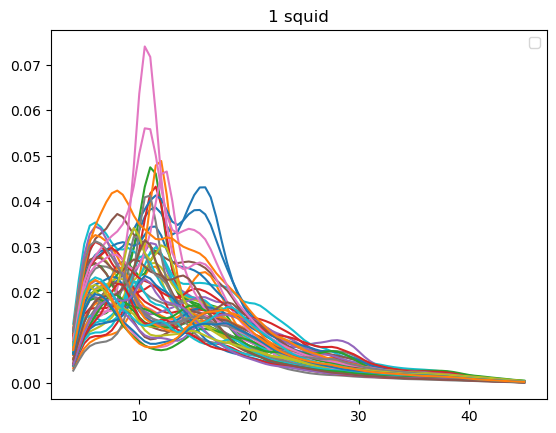

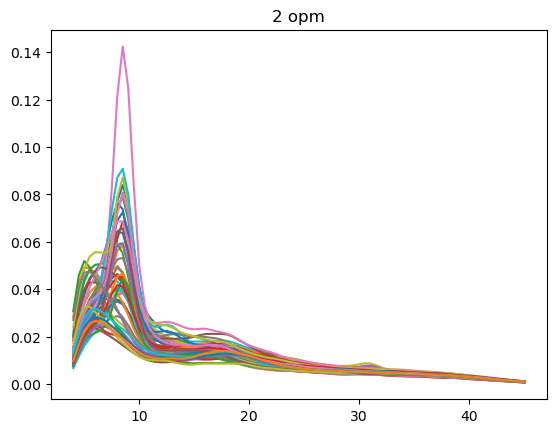

...

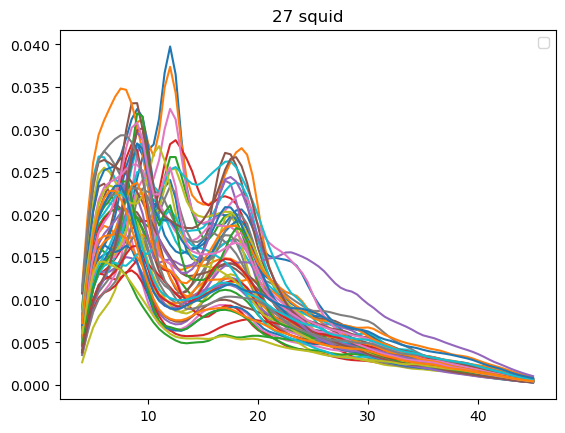

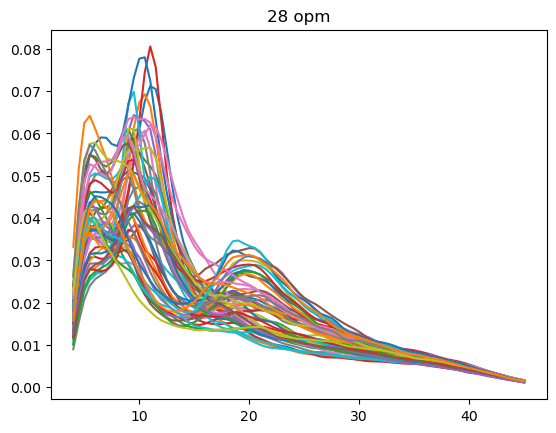

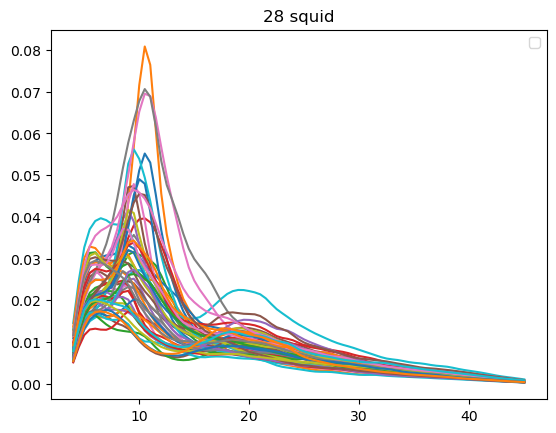

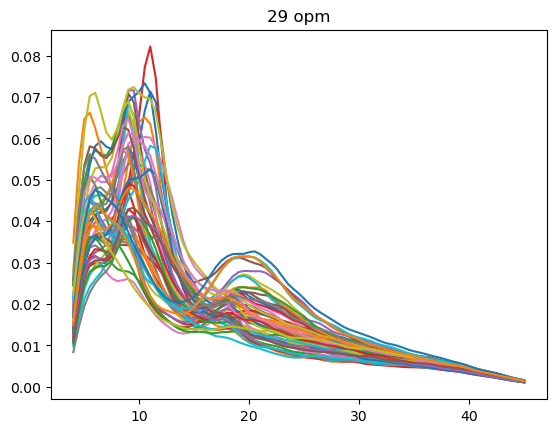

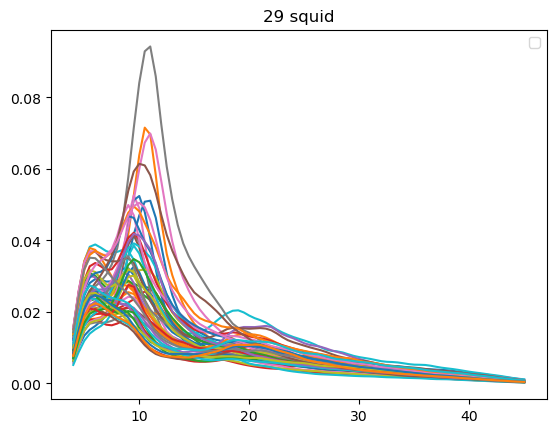

In [4]:
psds_list_cut_opm = []
psds_list_cut_squid = []
psds_av_opm = []
psds_av_squid = []

for sub in range(30):

    fig = plt.figure()
    plt.title(str(sub) + ' opm')
    subpsd_opm = psds_list_opms_parc[sub][:,8:91]
    psds_list_cut_opm.append(subpsd_opm)
    
    x = freqs_opms_parc[sub][8:91]
    y = np.mean(psds_list_cut_opm[sub],axis=0)
    y = y / np.sum(y)
    psds_av_opm.append(y)
    #plt.plot(x,y)

    for i in range(0,52):
        x = freqs_opms_parc[sub][8:91]
        y = psds_list_cut_opm[sub][i]
        plt.plot(x,y)

    fig = plt.figure()  
    plt.title(str(sub) + ' squid') 
    subpsd_squid = psds_list_squid_parc[sub][:,8:91]
    psds_list_cut_squid.append(subpsd_squid)

    x = freq_squid_parc[sub][8:91]
    y = np.mean(psds_list_cut_squid[sub],axis=0)
    y = y / np.sum(y)
    psds_av_squid.append(y)
    #plt.plot(x,y)

    for i in range(0,52):
        x = freq_squid_parc[sub][8:91]
        y = psds_list_cut_squid[sub][i]
        plt.plot(x,y)
        plt.legend()

/tmp/ipykernel_156748/989026489.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_156748/989026489.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


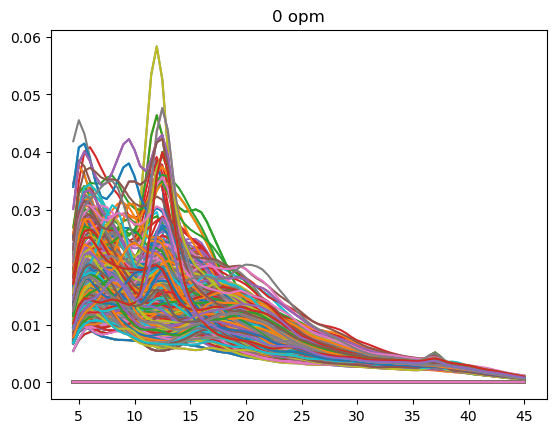

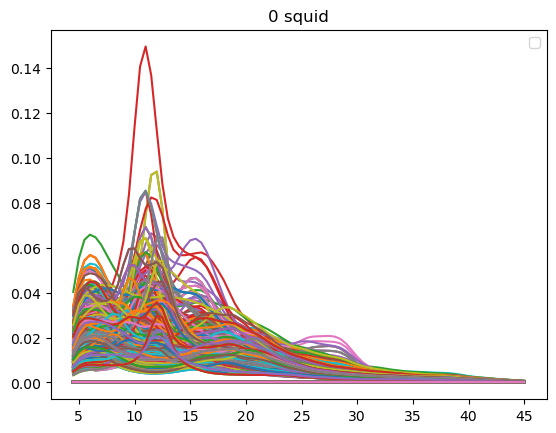

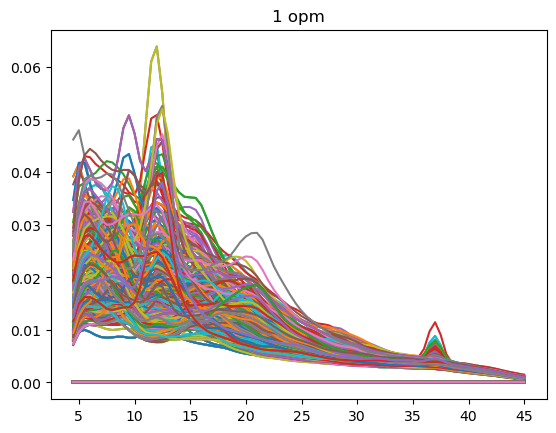

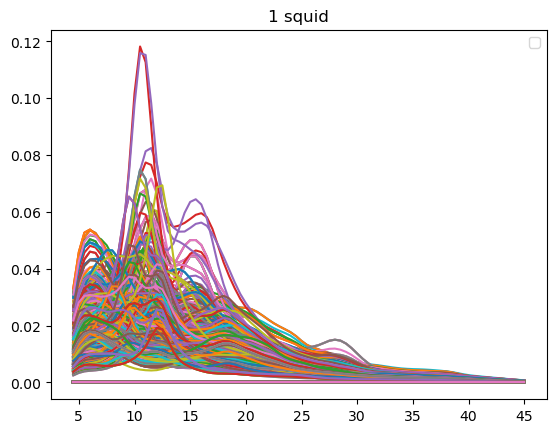

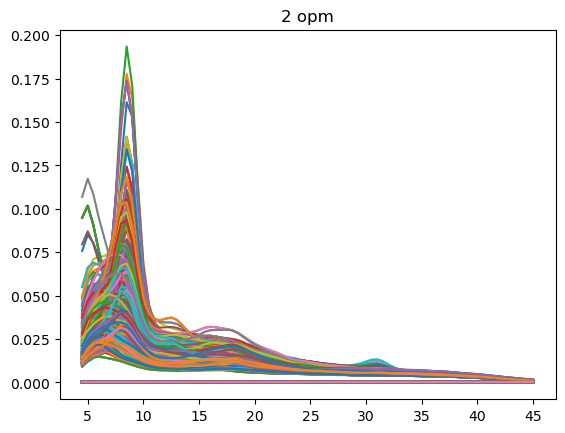

...

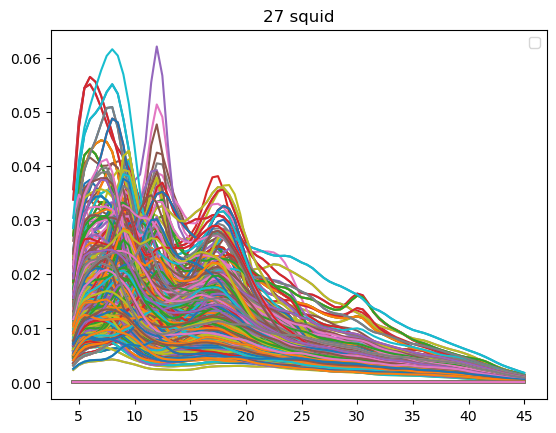

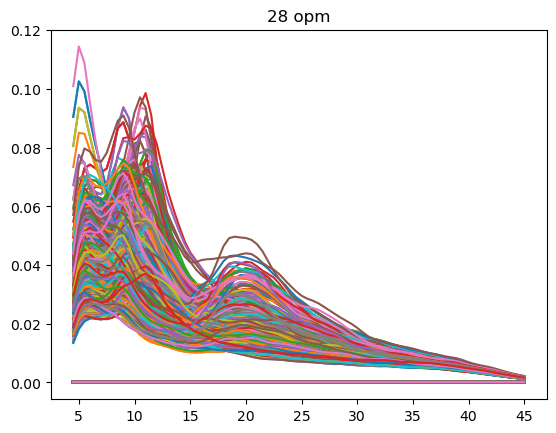

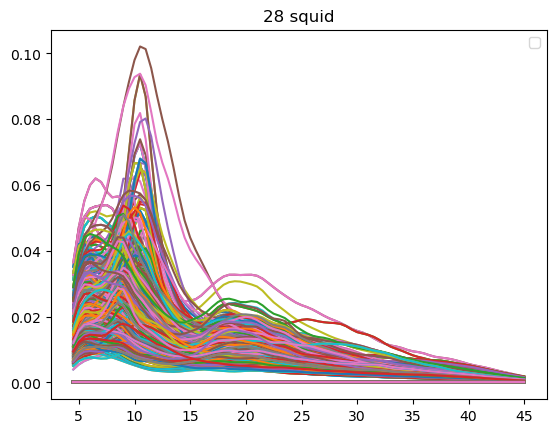

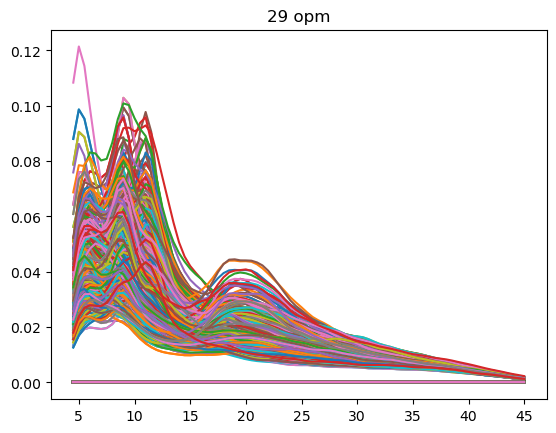

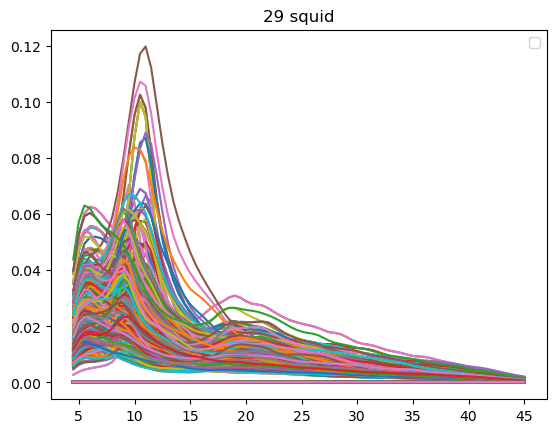

In [5]:
psds_list_cut_opm_beam = []
psds_list_cut_squid_beam = []
psds_av_opm_beam = []
psds_av_squid_beam = []

for sub in range(30):

    fig = plt.figure()
    plt.title(str(sub) + ' opm')
    subpsd_opm = psds_list_opms_beam[sub][:,9:91]
    psds_list_cut_opm_beam.append(subpsd_opm)
    
    x = freqs_opms_beam[sub][9:91]
    y = np.mean(psds_list_cut_opm_beam[sub],axis=0)
    y = y / np.sum(y)
    psds_av_opm_beam.append(y)
    #plt.plot(x,y)

    for i in range(0,677):
        x = freqs_opms_beam[sub][9:91]
        y = psds_list_cut_opm_beam[sub][i]
        plt.plot(x,y)

    fig = plt.figure()  
    plt.title(str(sub) + ' squid') 
    subpsd_squid = psds_list_squid_beam[sub][:,9:91]
    psds_list_cut_squid_beam.append(subpsd_squid)

    x = freq_squid_beam[sub][9:91]
    y = np.mean(psds_list_cut_squid_beam[sub],axis=0)
    y = y / np.sum(y)
    psds_av_squid_beam.append(y)
    #plt.plot(x,y)

    for i in range(0,677):
        x = freq_squid_beam[sub][9:91]
        y = psds_list_cut_squid_beam[sub][i]
        plt.plot(x,y)
        plt.legend()

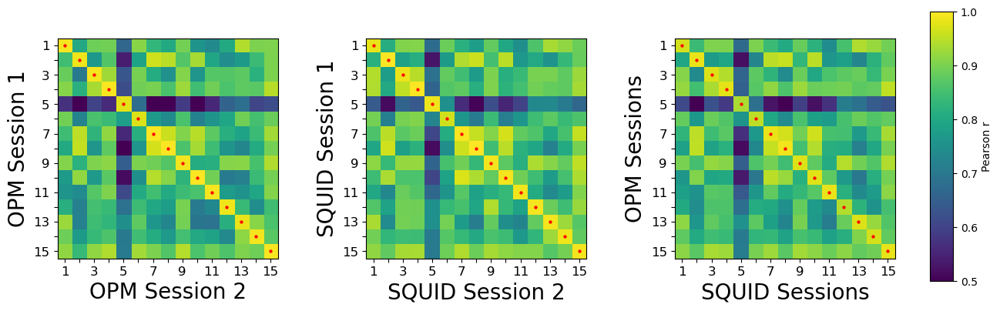

In [13]:
# OPM_1_psd = np.array(psds_list_cut_opm[::2])#[:,350:351,:] #psds_av_opm[::2] #psds_list_cut_opm[::2]
# OPM_2_psd = np.array(psds_list_cut_opm[1::2])#[:,350:351,:] 
# SQUID_1_psd = np.array(psds_list_cut_squid[::2])#[:,350:351,:] 
# SQUID_2_psd = np.array(psds_list_cut_squid[1::2])#[:,350:351,:] 

# psd_OPM1_OPM2_corr = np.zeros((15,15))
# psd_SQUID1_SQUID2_corr = np.zeros((15,15))
# psd_OPM_SQUID_corr = np.zeros((15,15))

# for row in range(15):
#     for colomn in range(15):
#             psd_OPM1_OPM2_corr[row,colomn] = scipy.stats.pearsonr(OPM_1_psd[row].ravel(),OPM_2_psd[colomn].ravel())[0]
#             psd_SQUID1_SQUID2_corr[row,colomn] = scipy.stats.pearsonr(SQUID_1_psd[row].ravel(),SQUID_2_psd[colomn].ravel())[0]
        
#             psd_OPM1_SQUID1_corr = scipy.stats.pearsonr(OPM_1_psd[row].ravel(),SQUID_1_psd[colomn].ravel())[0]
#             psd_OPM1_SQUID2_corr = scipy.stats.pearsonr(OPM_1_psd[row].ravel(),SQUID_2_psd[colomn].ravel())[0]
#             psd_OPM2_SQUID1_corr = scipy.stats.pearsonr(OPM_2_psd[row].ravel(),SQUID_1_psd[colomn].ravel())[0]
#             psd_OPM2_SQUID2_corr = scipy.stats.pearsonr(OPM_2_psd[row].ravel(),SQUID_2_psd[colomn].ravel())[0]

#             psd_OPM_SQUID_corr[row,colomn] = np.mean((psd_OPM1_SQUID1_corr, psd_OPM1_SQUID2_corr, psd_OPM2_SQUID1_corr, psd_OPM2_SQUID2_corr))





# mats = [psd_OPM1_OPM2_corr, psd_SQUID1_SQUID2_corr, psd_OPM_SQUID_corr]  # <- replace with your 3 matrices
# titles = ['','',''] #['psd_OPM1_OPM2_corr', 'psd_SQUID1_SQUID2_corr', 'psd_OPM_SQUID_corr']
# y_axis_labels = ['OPM Session 1', 'SQUID Session 1', 'OPM Sessions']
# x_axis_labels = ['OPM Session 2', 'SQUID Session 2', 'SQUID Sessions']

#---------------------------------------------------
#---------------------------
parcels = range(52)

psd_OPM1_OPM2_corr_parcels = np.zeros((len(parcels), 15, 15))
psd_SQUID1_SQUID2_corr_parcels = np.zeros((len(parcels), 15, 15))
psd_OPM_SQUID_corr_parcels = np.zeros((len(parcels), 15, 15))

OPM_1_psd = np.array(psds_list_cut_opm[::2])
OPM_2_psd = np.array(psds_list_cut_opm[1::2])
SQUID_1_psd = np.array(psds_list_cut_squid[::2])
SQUID_2_psd = np.array(psds_list_cut_squid[1::2])

for p_idx, parcel in enumerate(parcels):

    OPM_1 = OPM_1_psd[:, parcel, :]
    OPM_2 = OPM_2_psd[:, parcel, :]
    SQUID_1 = SQUID_1_psd[:, parcel, :]
    SQUID_2 = SQUID_2_psd[:, parcel, :]

    for row in range(15):
        for column in range(15):

            psd_OPM1_OPM2_corr_parcels[p_idx, row, column] = scipy.stats.pearsonr(
                OPM_1[row].flatten(),
                OPM_2[column].flatten()
            )[0]

            psd_SQUID1_SQUID2_corr_parcels[p_idx, row, column] = scipy.stats.pearsonr(
                SQUID_1[row].flatten(),
                SQUID_2[column].flatten()
            )[0]

            psd_OPM1_SQUID1_corr = scipy.stats.pearsonr(
                OPM_1[row].flatten(),
                SQUID_1[column].flatten()
            )[0]

            psd_OPM1_SQUID2_corr = scipy.stats.pearsonr(
                OPM_1[row].flatten(),
                SQUID_2[column].flatten()
            )[0]

            psd_OPM2_SQUID1_corr = scipy.stats.pearsonr(
                OPM_2[row].flatten(),
                SQUID_1[column].flatten()
            )[0]

            psd_OPM2_SQUID2_corr = scipy.stats.pearsonr(
                OPM_2[row].flatten(),
                SQUID_2[column].flatten()
            )[0]

            psd_OPM_SQUID_corr_parcels[p_idx, row, column] = np.mean([
                psd_OPM1_SQUID1_corr,
                psd_OPM1_SQUID2_corr,
                psd_OPM2_SQUID1_corr,
                psd_OPM2_SQUID2_corr
            ])

# average over the 52 parcels
psd_OPM1_OPM2_corr = np.mean(psd_OPM1_OPM2_corr_parcels, axis=0)
psd_SQUID1_SQUID2_corr = np.mean(psd_SQUID1_SQUID2_corr_parcels, axis=0)
psd_OPM_SQUID_corr = np.mean(psd_OPM_SQUID_corr_parcels, axis=0)

mats = [psd_OPM1_OPM2_corr, psd_SQUID1_SQUID2_corr, psd_OPM_SQUID_corr]  # <- replace with your 3 matrices
titles = ['','',''] #['psd_OPM1_OPM2_corr', 'psd_SQUID1_SQUID2_corr', 'psd_OPM_SQUID_corr']
y_axis_labels = ['OPM Session 1', 'SQUID Session 1', 'OPM Sessions']
x_axis_labels = ['OPM Session 2', 'SQUID Session 2', 'SQUID Sessions']
#-------------------------------------------------------

# fig, axes = plt.subplots(1, 3, figsize=(15, 5))#, sharex=True, sharey=True)

# for ax, mat, title, x_axis, y_axis in zip(axes, mats, titles, x_axis_labels, y_axis_labels):
#     im = ax.imshow(mat, cmap='OrRd', vmin=0.5, vmax=1)

#     ax.set_title(title)
#     ax.set_xlabel(x_axis, fontsize=20)
#     ax.set_ylabel(y_axis, fontsize=20)

#     # mark row-wise maxima
#     n_rows = mat.shape[0]
#     for i in range(n_rows):
#         j_max = np.argmax(mat[i, :])
#         ax.scatter(j_max, i, color='yellow', marker='.', s=1, linewidths=2)

# # one shared colorbar
# fig.colorbar(im, ax=axes, label='Pearson r')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(wspace=0.4)

# leave space on the right
fig.subplots_adjust(right=0.85)

cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])  # [left, bottom, width, height]

# subject labels (skip 8)
labels = [1,'',3,'',5,'',7,'',9,'',11,'',13,'',15]

for ax, mat, title, x_axis, y_axis in zip(axes, mats, titles, x_axis_labels, y_axis_labels):
    im = ax.imshow(mat, cmap='viridis', vmin=0.5, vmax=1)
    ax.set_title(title)
    ax.set_xlabel(x_axis, fontsize=20)
    ax.set_ylabel(y_axis, fontsize=20)

    # --- set ticks ---
    n = mat.shape[0]
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))

    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.tick_params(axis='both', labelsize=12) #anna change add
    

    for i in range(mat.shape[0]):
        j_max = np.argmax(mat[i, :])
        ax.scatter(j_max, i, color='red', marker='.', s=5, linewidths=2)

fig.colorbar(im, cax=cbar_ax, label='Pearson r')

#plt.tight_layout()
plt.show()

In [15]:
#Saving corr matrices 

base = "/rdrives/DRS-foundation-brain/zoe_data/BIDS"
deriv = f"{base}/derivatives_anna_01042026"
corr_dir = f"{deriv}/correlations_matrices"
os.makedirs(corr_dir, exist_ok=True)
corr_dir2 = f"{corr_dir}/OPM_SQUID_noorthog"
os.makedirs(corr_dir2, exist_ok=True)
state_dir = f"{corr_dir2}/static_psds"
os.makedirs(state_dir, exist_ok=True)

# Save
np.save(f'{state_dir}/OPM1_OPM2_parcel_psds.npy', psd_OPM1_OPM2_corr)
np.save(f'{state_dir}/SQUID1_SQUID2_parcel_psds.npy', psd_SQUID1_SQUID2_corr)
np.save(f'{state_dir}/OPM_SQUID_parcel_psds.npy', psd_OPM_SQUID_corr)

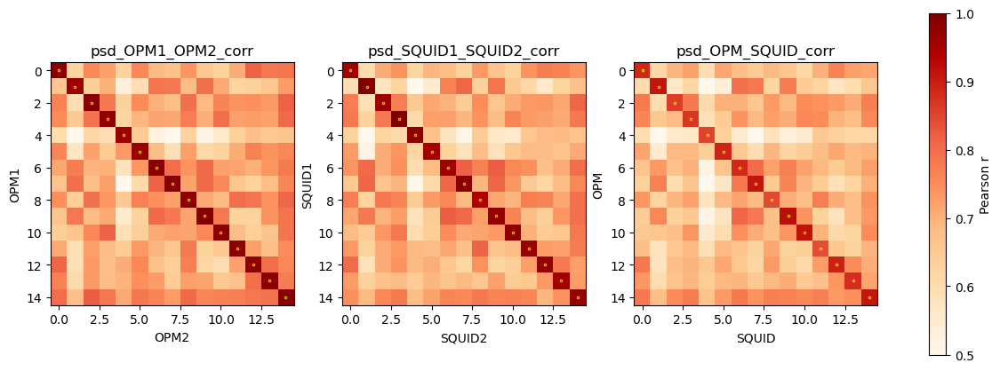

In [7]:
OPM_1_psd = np.array(psds_list_cut_opm_beam[::2])#[:,350:351,:] #psds_av_opm[::2] #psds_list_cut_opm[::2]
OPM_2_psd = np.array(psds_list_cut_opm_beam[1::2])#[:,350:351,:] 
SQUID_1_psd = np.array(psds_list_cut_squid_beam[::2])#[:,350:351,:] 
SQUID_2_psd = np.array(psds_list_cut_squid_beam[1::2])#[:,350:351,:] 

psd_OPM1_OPM2_corr = np.zeros((15,15))
psd_SQUID1_SQUID2_corr = np.zeros((15,15))
psd_OPM_SQUID_corr = np.zeros((15,15))

for row in range(15):
    for colomn in range(15):
            psd_OPM1_OPM2_corr[row,colomn] = scipy.stats.pearsonr(OPM_1_psd[row].ravel(),OPM_2_psd[colomn].ravel())[0]
            psd_SQUID1_SQUID2_corr[row,colomn] = scipy.stats.pearsonr(SQUID_1_psd[row].ravel(),SQUID_2_psd[colomn].ravel())[0]
        
            psd_OPM1_SQUID1_corr = scipy.stats.pearsonr(OPM_1_psd[row].ravel(),SQUID_1_psd[colomn].ravel())[0]
            psd_OPM1_SQUID2_corr = scipy.stats.pearsonr(OPM_1_psd[row].ravel(),SQUID_2_psd[colomn].ravel())[0]
            psd_OPM2_SQUID1_corr = scipy.stats.pearsonr(OPM_2_psd[row].ravel(),SQUID_1_psd[colomn].ravel())[0]
            psd_OPM2_SQUID2_corr = scipy.stats.pearsonr(OPM_2_psd[row].ravel(),SQUID_2_psd[colomn].ravel())[0]

            psd_OPM_SQUID_corr[row,colomn] = np.mean((psd_OPM1_SQUID1_corr, psd_OPM1_SQUID2_corr, psd_OPM2_SQUID1_corr, psd_OPM2_SQUID2_corr))



mats = [psd_OPM1_OPM2_corr, psd_SQUID1_SQUID2_corr, psd_OPM_SQUID_corr]  # <- replace with your 3 matrices
titles = ['psd_OPM1_OPM2_corr', 'psd_SQUID1_SQUID2_corr', 'psd_OPM_SQUID_corr']
y_axis_labels = ['OPM1', 'SQUID1', 'OPM']
x_axis_labels = ['OPM2', 'SQUID2', 'SQUID']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))#, sharex=True, sharey=True)

for ax, mat, title, x_axis, y_axis in zip(axes, mats, titles, x_axis_labels, y_axis_labels):
    im = ax.imshow(mat, cmap='OrRd', vmin=0.5, vmax=1)

    ax.set_title(title)
    ax.set_xlabel(x_axis)
    ax.set_ylabel(y_axis)

    # mark row-wise maxima
    n_rows = mat.shape[0]
    for i in range(n_rows):
        j_max = np.argmax(mat[i, :])
        ax.scatter(j_max, i, color='yellow', marker='.', s=1, linewidths=2)

# one shared colorbar
fig.colorbar(im, ax=axes, label='Pearson r')

#plt.tight_layout()
plt.show()

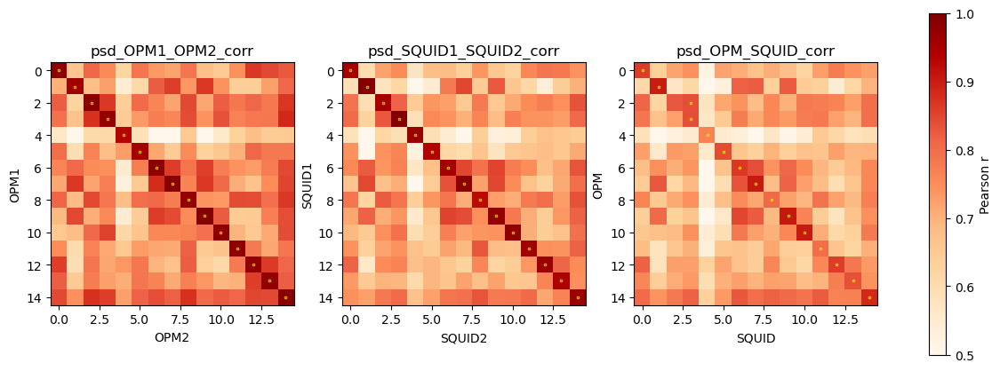

In [8]:
OPM_1_psd = np.array(psds_list_cut_opm_beam[::2])#[:,350:351,:] #psds_av_opm[::2] #psds_list_cut_opm[::2]
OPM_2_psd = np.array(psds_list_cut_opm_beam[1::2])#[:,350:351,:] 
SQUID_1_psd = np.array(psds_list_cut_squid_beam[::2])#[:,350:351,:] 
SQUID_2_psd = np.array(psds_list_cut_squid_beam[1::2])#[:,350:351,:] 

psd_OPM1_OPM2_corr = np.zeros((15,15))
psd_SQUID1_SQUID2_corr = np.zeros((15,15))
psd_OPM_SQUID_corr = np.zeros((15,15))

for row in range(15):
    for colomn in range(15):
            
            # Create masks for non-zero signals
            mask_opm1 = OPM_1_psd[row] != 0
            mask_opm2 = OPM_2_psd[colomn] != 0
            mask_squid1 = SQUID_1_psd[row] != 0
            mask_squid2 = SQUID_2_psd[colomn] != 0

            # Combine masks to find common non-zero voxels
            combined_mask_opm = mask_opm1 & mask_opm2
            combined_mask_squid = mask_squid1 & mask_squid2
            combined_mask_opm_squid = mask_opm1 & mask_squid2 #opm1 and squid2 as corresponds to opms being selected by row and squids by colomn, so this is the mask for the opm-squid correlations


            psd_OPM1_OPM2_corr[row,colomn] = scipy.stats.pearsonr(OPM_1_psd[row][combined_mask_opm].ravel(),OPM_2_psd[colomn][combined_mask_opm].ravel())[0]
            psd_SQUID1_SQUID2_corr[row,colomn] = scipy.stats.pearsonr(SQUID_1_psd[row][combined_mask_squid].ravel(),SQUID_2_psd[colomn][combined_mask_squid].ravel())[0]
        
            psd_OPM1_SQUID1_corr = scipy.stats.pearsonr(OPM_1_psd[row][combined_mask_opm_squid].ravel(),SQUID_1_psd[colomn][combined_mask_opm_squid].ravel())[0]
            psd_OPM1_SQUID2_corr = scipy.stats.pearsonr(OPM_1_psd[row][combined_mask_opm_squid].ravel(),SQUID_2_psd[colomn][combined_mask_opm_squid].ravel())[0]
            psd_OPM2_SQUID1_corr = scipy.stats.pearsonr(OPM_2_psd[row][combined_mask_opm_squid].ravel(),SQUID_1_psd[colomn][combined_mask_opm_squid].ravel())[0]
            psd_OPM2_SQUID2_corr = scipy.stats.pearsonr(OPM_2_psd[row][combined_mask_opm_squid].ravel(),SQUID_2_psd[colomn][combined_mask_opm_squid].ravel())[0]

            psd_OPM_SQUID_corr[row,colomn] = np.mean((psd_OPM1_SQUID1_corr, psd_OPM1_SQUID2_corr, psd_OPM2_SQUID1_corr, psd_OPM2_SQUID2_corr))



mats = [psd_OPM1_OPM2_corr, psd_SQUID1_SQUID2_corr, psd_OPM_SQUID_corr]  # <- replace with your 3 matrices
titles = ['psd_OPM1_OPM2_corr', 'psd_SQUID1_SQUID2_corr', 'psd_OPM_SQUID_corr']
y_axis_labels = ['OPM1', 'SQUID1', 'OPM']
x_axis_labels = ['OPM2', 'SQUID2', 'SQUID']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))#, sharex=True, sharey=True)

for ax, mat, title, x_axis, y_axis in zip(axes, mats, titles, x_axis_labels, y_axis_labels):
    im = ax.imshow(mat, cmap='OrRd', vmin=0.5, vmax=1)

    ax.set_title(title)
    ax.set_xlabel(x_axis)
    ax.set_ylabel(y_axis)

    # mark row-wise maxima
    n_rows = mat.shape[0]
    for i in range(n_rows):
        j_max = np.argmax(mat[i, :])
        ax.scatter(j_max, i, color='yellow', marker='.', s=1, linewidths=2)

# one shared colorbar
fig.colorbar(im, ax=axes, label='Pearson r')

#plt.tight_layout()
plt.show()

In [ ]:
##CALCULATING ALPHA AND BETA POWER IN THE BRAIN

OPM1_p_whole = []
OPM2_p_whole = []
SQUID1_p_whole = []
SQUID2_p_whole = []

OPM1_p_alpha = []
OPM2_p_alpha = []
SQUID1_p_alpha = []
SQUID2_p_alpha = []

OPM1_p_beta = []
OPM2_p_beta = []
SQUID1_p_beta = []
SQUID2_p_beta = []

alpha_range_inds = (8,18) #from 8 to 13
beta_range_inds = (18,52) #from 13 to 30

for subject in range(15):

    df = 0.5  # frequency resolution

    # psd shape: (52, 82)
    OPM1_power_whole = np.sum(OPM_1_psd[subject], axis=1) * df 
    OPM1_p_whole.append(OPM1_power_whole)
    OPM2_power_whole = np.sum(OPM_2_psd[subject], axis=1) * df 
    OPM2_p_whole.append(OPM2_power_whole)
    SQUID1_power_whole = np.sum(SQUID_1_psd[subject], axis=1) * df
    SQUID1_p_whole.append(SQUID1_power_whole)
    SQUID2_power_whole = np.sum(SQUID_2_psd[subject], axis=1) * df
    SQUID2_p_whole.append(SQUID2_power_whole)

    OPM1_power_alpha = np.sum(OPM_1_psd[subject,:, alpha_range_inds[0]:alpha_range_inds[1]], axis=1) * df 
    OPM1_power_alpha = OPM1_power_alpha/OPM1_power_whole
    OPM1_p_alpha.append(OPM1_power_alpha)
    OPM2_power_alpha = np.sum(OPM_2_psd[subject,:, alpha_range_inds[0]:alpha_range_inds[1]], axis=1) * df 
    OPM2_power_alpha = OPM2_power_alpha/OPM2_power_whole
    OPM2_p_alpha.append(OPM2_power_alpha)
    SQUID1_power_alpha = np.sum(SQUID_1_psd[subject,:, alpha_range_inds[0]:alpha_range_inds[1]], axis=1) * df
    SQUID1_power_alpha = SQUID1_power_alpha/SQUID1_power_whole
    SQUID1_p_alpha.append(SQUID1_power_alpha)
    SQUID2_power_alpha = np.sum(SQUID_2_psd[subject,:, alpha_range_inds[0]:alpha_range_inds[1]], axis=1) * df
    SQUID2_power_alpha = SQUID2_power_alpha/SQUID2_power_whole
    SQUID2_p_alpha.append(SQUID2_power_alpha)

    OPM1_power_beta = np.sum(OPM_1_psd[subject,:, beta_range_inds[0]:beta_range_inds[1]], axis=1) * df 
    OPM1_power_beta = OPM1_power_beta/OPM1_power_whole
    OPM1_p_beta.append(OPM1_power_beta)
    OPM2_power_beta = np.sum(OPM_2_psd[subject,:, beta_range_inds[0]:beta_range_inds[1]], axis=1) * df 
    OPM2_power_beta = OPM2_power_beta/OPM2_power_whole
    OPM2_p_beta.append(OPM2_power_beta)
    SQUID1_power_beta = np.sum(SQUID_1_psd[subject,:, beta_range_inds[0]:beta_range_inds[1]], axis=1) * df
    SQUID1_power_beta = SQUID1_power_beta/SQUID1_power_whole
    SQUID1_p_beta.append(SQUID1_power_beta)
    SQUID2_power_beta = np.sum(SQUID_2_psd[subject,:, beta_range_inds[0]:beta_range_inds[1]], axis=1) * df
    SQUID2_power_beta = SQUID2_power_beta/SQUID2_power_whole
    SQUID2_p_beta.append(SQUID2_power_beta)

    



Saving images:   0%|          | 0/1 [00:00<?, ?it/s]

Saving images:   0%|          | 0/1 [00:00<?, ?it/s]

Saving images:   0%|          | 0/1 [00:00<?, ?it/s]

Saving images:   0%|          | 0/1 [00:00<?, ?it/s]

([<Figure size 768x480 with 3 Axes>], [[<Axes3D: >, <Axes3D: >]])

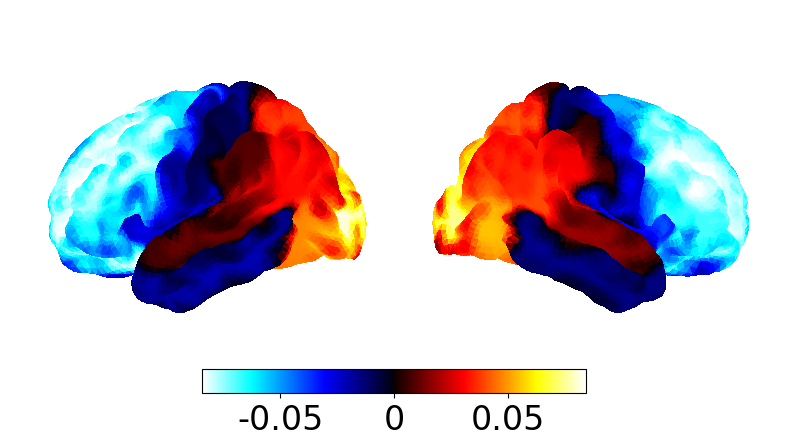

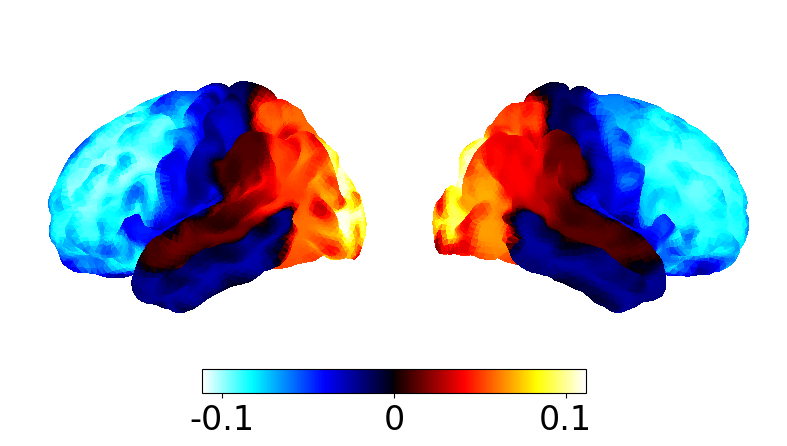

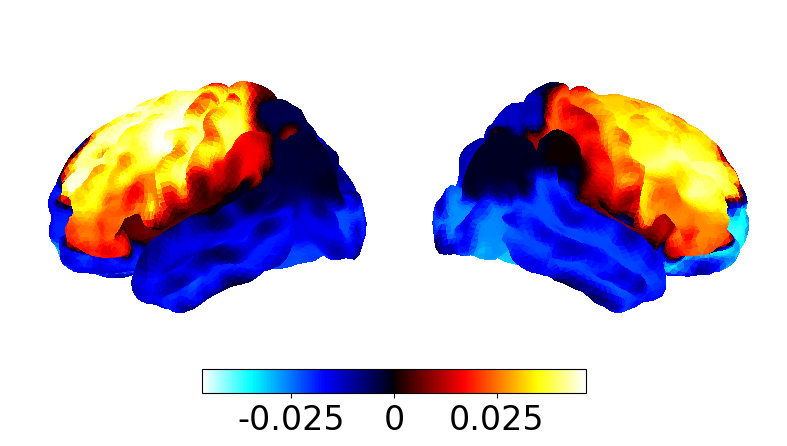

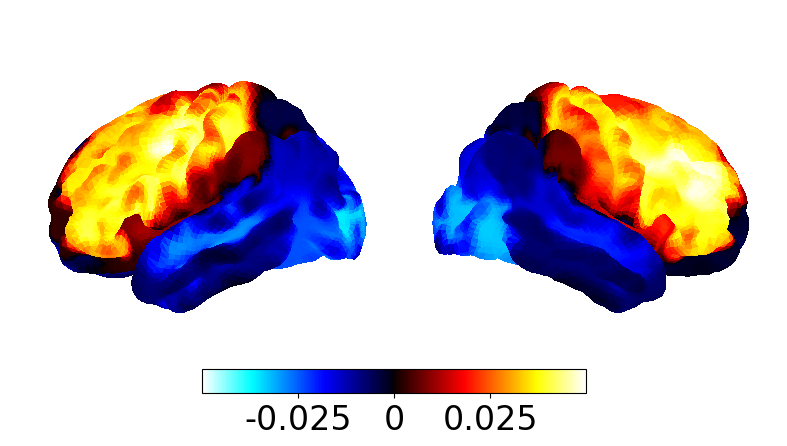

In [ ]:
#PLOTTING ALPHA AND BETA POWER IN THE BRAIN

from osl_dynamics.analysis import power
from osl_dynamics.utils import plotting

# values = OPM2_p_beta[0].flatten()
# mean_value = np.mean(values)
# value_meaned = values - mean_value
#values_plot = ((((values - 0.9) / (1.0 - 0.9)) * 2) - 1)  # normalize to [-1, 1] range for better visualization

subjects = ['001', '002', '003', '004', '005', '006', '007', '009', '010', '011', '012', '013', '014', '015', '016']
figs_dir = '/rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/static_figures/freq_band_powermaps'
alp_OPM_all = []
alp_SQUID_all = []
beta_OPM_all = []
beta_SQUID_all = []

for sub in range(15):

    alpha_OPM1 = OPM1_p_alpha[sub].flatten()
    mean_alp_OPM1 = np.mean(alpha_OPM1)
    alp_OPM1_demeaned = alpha_OPM1 - mean_alp_OPM1
    alp_OPM_all.append(alpha_OPM1)

    # filename_alp_opm1 = f'sub-{subjects[sub]}_ses-001_task-braille_run-001_alphaband_powermap_notstandardised.png'
    # power.save(
    #     alp_OPM1_demeaned,
    #     mask_file="MNI152_T1_8mm_brain.nii.gz",
    #     parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
    #     filename= f"{figs_dir}/{filename_alp_opm1}"
    # )

    alpha_OPM2 = OPM2_p_alpha[sub].flatten()
    mean_alp_OPM2 = np.mean(alpha_OPM2)
    alp_OPM2_demeaned = alpha_OPM2 - mean_alp_OPM2
    alp_OPM_all.append(alpha_OPM2)

    # filename_alp_opm2 = f'sub-{subjects[sub]}_ses-002_task-braille_run-001_alphaband_powermap_notstandardised.png'
    # power.save(
    #     alp_OPM2_demeaned,
    #     mask_file="MNI152_T1_8mm_brain.nii.gz",
    #     parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
    #     filename= f"{figs_dir}/{filename_alp_opm2}"
    # )

    alpha_SQUID1 = SQUID1_p_alpha[sub].flatten()
    mean_alp_SQUID1 = np.mean(alpha_SQUID1)
    alp_SQUID1_demeaned = alpha_SQUID1 - mean_alp_SQUID1
    alp_SQUID_all.append(alpha_SQUID1)

    # filename_alp_squid1 = f'sub-{subjects[sub]}_ses-003_task-braille_run-001_alphaband_powermap_notstandardised.png'
    # power.save(
    #     alp_SQUID1_demeaned,
    #     mask_file="MNI152_T1_8mm_brain.nii.gz",
    #     parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
    #     filename= f"{figs_dir}/{filename_alp_squid1}"
    # )

    alpha_SQUID2 = SQUID2_p_alpha[sub].flatten()
    mean_alp_SQUID2 = np.mean(alpha_SQUID2)
    alp_SQUID2_demeaned = alpha_SQUID2 - mean_alp_SQUID2
    alp_SQUID_all.append(alpha_SQUID2)

    # filename_alp_squid2 = f'sub-{subjects[sub]}_ses-004_task-braille_run-001_alphaband_powermap_notstandardised.png'
    # power.save(
    #     alp_SQUID2_demeaned,
    #     mask_file="MNI152_T1_8mm_brain.nii.gz",
    #     parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
    #     filename= f"{figs_dir}/{filename_alp_squid2}"
    # )



    beta_OPM1 = OPM1_p_beta[sub].flatten()
    mean_beta_OPM1 = np.mean(beta_OPM1)
    beta_OPM1_demeaned = beta_OPM1 - mean_beta_OPM1
    beta_OPM_all.append(beta_OPM1)

    # filename_beta_opm1 = f'sub-{subjects[sub]}_ses-001_task-braille_run-001_betaband_powermap_notstandardised.png'
    # power.save(
    #     beta_OPM1_demeaned,
    #     mask_file="MNI152_T1_8mm_brain.nii.gz",
    #     parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
    #     filename= f"{figs_dir}/{filename_beta_opm1}"
    # )

    beta_OPM2 = OPM2_p_beta[sub].flatten()
    mean_beta_OPM2 = np.mean(beta_OPM2)
    beta_OPM2_demeaned = beta_OPM2 - mean_beta_OPM2
    beta_OPM_all.append(beta_OPM2)

    # filename_beta_opm2 = f'sub-{subjects[sub]}_ses-002_task-braille_run-001_betaband_powermap_notstandardised.png'
    # power.save(
    #     beta_OPM2_demeaned,
    #     mask_file="MNI152_T1_8mm_brain.nii.gz",
    #     parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
    #     filename= f"{figs_dir}/{filename_beta_opm2}"
    # )

    beta_SQUID1 = SQUID1_p_beta[sub].flatten()
    mean_beta_SQUID1 = np.mean(beta_SQUID1)
    beta_SQUID1_demeaned = beta_SQUID1 - mean_beta_SQUID1
    beta_SQUID_all.append(beta_SQUID1)

    # filename_beta_squid1 = f'sub-{subjects[sub]}_ses-003_task-braille_run-001_betaband_powermap_notstandardised.png'
    # power.save(
    #     beta_SQUID1_demeaned,
    #     mask_file="MNI152_T1_8mm_brain.nii.gz",
    #     parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
    #     filename= f"{figs_dir}/{filename_beta_squid1}"
    # )

    beta_SQUID2 = SQUID2_p_beta[sub].flatten()
    mean_beta_SQUID2 = np.mean(beta_SQUID2)
    beta_SQUID2_demeaned = beta_SQUID2 - mean_beta_SQUID2
    beta_SQUID_all.append(beta_SQUID2)

    # filename_beta_squid2 = f'sub-{subjects[sub]}_ses-004_task-braille_run-001_betaband_powermap_notstandardised.png'
    # power.save(
    #     beta_SQUID2_demeaned,
    #     mask_file="MNI152_T1_8mm_brain.nii.gz",
    #     parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
    #     filename= f"{figs_dir}/{filename_beta_squid2}"
    # )

alp_OPM_avg = np.mean(alp_OPM_all, axis=0)
mean_alp_OPM = np.mean(alp_OPM_avg)
alp_OPM_avg_demeaned = alp_OPM_avg - mean_alp_OPM
power.save(
    alp_OPM_avg_demeaned,
    mask_file="MNI152_T1_8mm_brain.nii.gz",
    parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
)

alp_SQUID_avg = np.mean(alp_SQUID_all, axis=0)
mean_alp_SQUID = np.mean(alp_SQUID_avg)
alp_SQUID_avg_demeaned = alp_SQUID_avg - mean_alp_SQUID
power.save(
    alp_SQUID_avg_demeaned,
    mask_file="MNI152_T1_8mm_brain.nii.gz",
    parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
)

beta_OPM_avg = np.mean(beta_OPM_all, axis=0)
mean_beta_OPM = np.mean(beta_OPM_avg)
beta_OPM_avg_demeaned = beta_OPM_avg - mean_beta_OPM
power.save(
    beta_OPM_avg_demeaned,
    mask_file="MNI152_T1_8mm_brain.nii.gz",
    parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
)

beta_SQUID_avg = np.mean(beta_SQUID_all, axis=0)
mean_beta_SQUID = np.mean(beta_SQUID_avg)
beta_SQUID_avg_demeaned = beta_SQUID_avg - mean_beta_SQUID
power.save(
    beta_SQUID_avg_demeaned,
    mask_file="MNI152_T1_8mm_brain.nii.gz",
    parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
)
    

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-05-06 11:57:58 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/osl_noorthog/sub-004_ses-004_task-braille_run-001/lcmv-parc-raw.fif...
    Range : 1743 ... 329334 =      6.972 ...  1317.336 secs
Ready.


pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-05-06 11:58:00 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-05-06 11:58:00 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/osl_noorthog/sub-004_ses-004_task-braille_run-001/lcmv-parc-raw.fif...
    Range : 1743 ... 329334 =      6.972 ...  1317.336 secs
Ready.


pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-05-06 11:58:01 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


<Figure size 640x480 with 0 Axes>

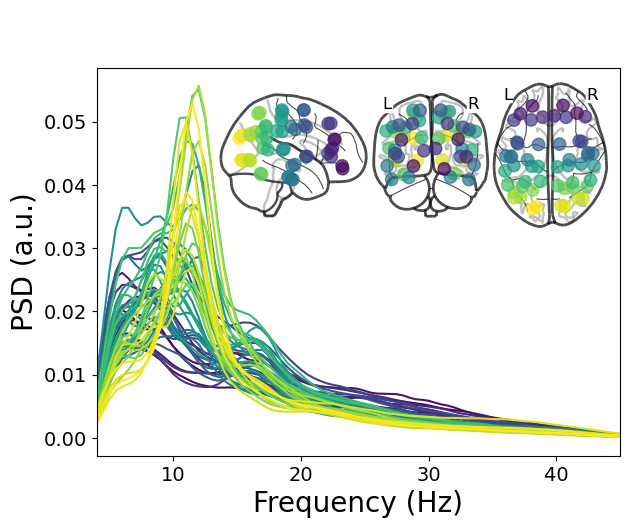

<Figure size 640x480 with 0 Axes>

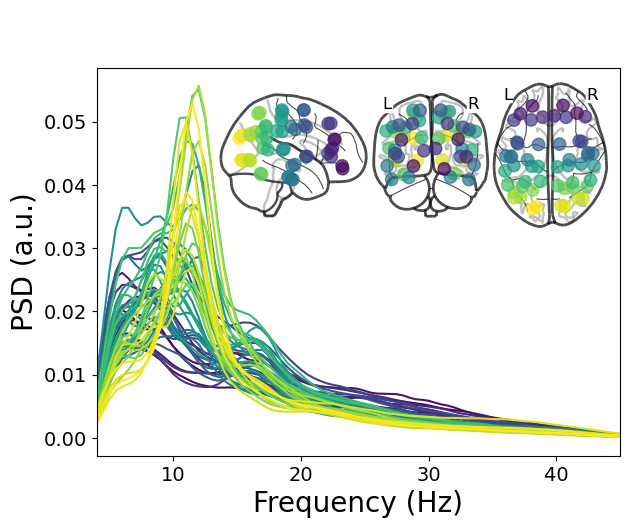

In [ ]:
#PLOTTING SINGULAR PERSONS PARCEL PSDs
from osl_dynamics.meeg import parcellation
import numpy as np
import matplotlib.pyplot as plt

#defining universal file locations
base = "/rdrives/DRS-foundation-brain/zoe_data/BIDS"
deriv = f"{base}/derivatives_anna_01042026"
outdir_osl= f"{deriv}/osl_noorthog"
id = f"sub-004_ses-004_task-braille_run-001"
parc_fif = (f"{outdir_osl}/{id}/lcmv-parc-raw.fif")
parcellationfile = "atlas-Glasser_nparc-52_space-MNI_res-8x8x8.nii.gz"


def get_parcel_ind(parcel_ind_list):

    new_parc_ind_list = []
    for parcel_ind in parcel_ind_list:
        from osl_dynamics.meeg.parcellation import Parcellation
        parcellation = Parcellation(parcellationfile)
        roi_centers = parcellation.roi_centers()
        order = np.argsort(roi_centers[:, 1])

        # Convert original index → reordered index
        new_ind = np.where(order == parcel_ind)[0][0]
        new_parc_ind_list.append(new_ind)

    return new_parc_ind_list

only_show = get_parcel_ind([0])

fig = plt.figure()
parcellation.plot_psds(parc_fif, parcellation_file=parcellationfile, fmin=4, only_show=only_show)#, filename=psdfile)


only_show = get_parcel_ind([51])

fig = plt.figure()
parcellation.plot_psds(parc_fif, parcellation_file=parcellationfile, fmin=4, only_show=only_show)#, filename=psdfile)


pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-05-13 00:00:36 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/osl_noorthog/sub-001_ses-001_task-braille_run-001/lcmv-parc-raw.fif...
    Range : 31930 ... 358698 =    127.720 ...  1434.792 secs
Ready.
Reading 0 ... 326768  =      0.000 ...  1307.072 secs...
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/osl_noorthog/sub-001_ses-002_task-braille_run-001/lcmv-parc-raw.fif...
    Range : 35501 ... 362221 =    142.004 ...  1448.884 secs
Ready.
Reading 0 ... 326720  =      0.000 ...  1306.880 secs...
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/osl_noorthog/sub-002_ses-001_task-braille_run-001/lcmv-parc-raw.fif...
    Range : 1924 ... 328319 =      7.696 ...  1313.276 secs
Ready.
Reading 0 ... 326395  =      0.000 ...  1305.580 secs...
Omitting 1500 of 326396 (0.46%) samples, retaining 324896 (99.54%) samples.
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-05-13 00:01:45 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/osl_noorthog/sub-001_ses-003_task-braille_run-001/lcmv-parc-raw.fif...
    Range : 17069 ... 337499 =     68.276 ...  1349.996 secs
Ready.
Reading 0 ... 320430  =      0.000 ...  1281.720 secs...
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/osl_noorthog/sub-001_ses-004_task-braille_run-001/lcmv-parc-raw.fif...
    Range : 2573 ... 330092 =     10.292 ...  1320.368 secs
Ready.
Reading 0 ... 327519  =      0.000 ...  1310.076 secs...
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/osl_noorthog/sub-002_ses-003_task-braille_run-001/lcmv-parc-raw.fif...
    Range : 1409 ... 328855 =      5.636 ...  1315.420 secs
Ready.
Reading 0 ... 327446  =      0.000 ...  1309.784 secs...
Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/osl_noorthog/sub-002_ses-004_task-braille_run-

pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1
2026-05-13 00:02:37 INFO nibabel.global [batteryrunners.py:268:log_raise]: pixdim[0] (qfac) should be 1 (default) or -1; setting qfac to 1


<Figure size 640x480 with 0 Axes>

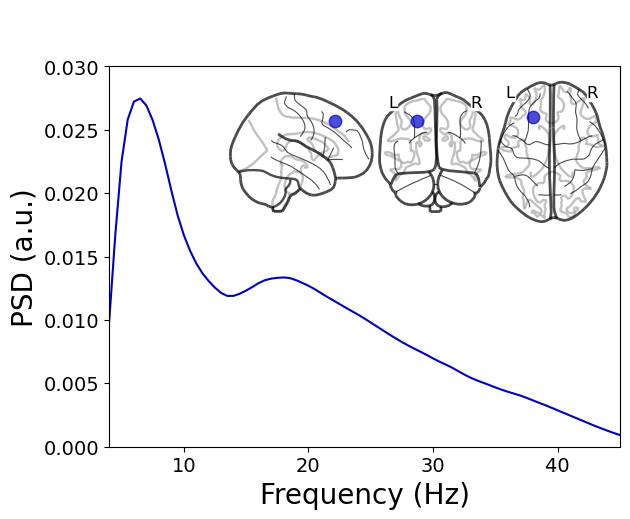

<Figure size 640x480 with 0 Axes>

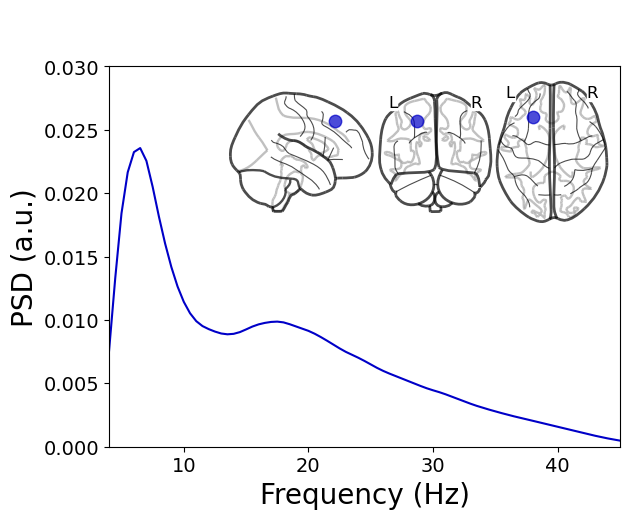

In [ ]:
#PLOTTING AVERAGE PARCEL PSDS ACROSS ALL SUBJECTS for OPMs and SQUIDs
subjects = ["001", "002", "003", "004", "005", "006", "007", "009", "010", "011", "012", "013", "014", "015", "016"] #"002", "003", "004", "005", "006", "007", # "001", "002", "003", "004", "005", "006", "007", "009", "010", "011", "012", "013", "014", "015", "016"
sessions_opms = ["001", "002"]
sessions_squids = ["003", "004"]
tasks = ["braille"]
runs = ["001"]

OPM_parc_name_list = []
SQUID_parc_name_list = []


base = "/rdrives/DRS-foundation-brain/zoe_data/BIDS"
deriv = f"{base}/derivatives_anna_01042026"
parcellationfile = "atlas-Glasser_nparc-52_space-MNI_res-8x8x8.nii.gz"

for subject in subjects:
    for session in sessions_opms:
        for task in tasks:
            for run in runs:

                id = f"sub-{subject}_ses-{session}_task-{task}_run-{run}"
                parc_fif_opms = (f"{deriv}/osl_noorthog/{id}/lcmv-parc-raw.fif")
                OPM_parc_name_list.append(parc_fif_opms)

    

    for session in sessions_squids:
        for task in tasks:
            for run in runs:

                id = f"sub-{subject}_ses-{session}_task-{task}_run-{run}"
                parc_fif_squids = (f"{deriv}/osl_noorthog/{id}/lcmv-parc-raw.fif")
                SQUID_parc_name_list.append(parc_fif_squids)

def get_parcel_ind(parcel_ind_list):

    new_parc_ind_list = []
    for parcel_ind in parcel_ind_list:
        from osl_dynamics.meeg.parcellation import Parcellation
        parcellation = Parcellation(parcellationfile)
        roi_centers = parcellation.roi_centers()
        order = np.argsort(roi_centers[:, 1])

        # Convert original index → reordered index
        new_ind = np.where(order == parcel_ind)[0][0]
        new_parc_ind_list.append(new_ind)

    return new_parc_ind_list

only_show = get_parcel_ind([51])
fig = plt.figure()
parcellation.plot_psds_average(OPM_parc_name_list, parcellation_file=parcellationfile, fmin=4, only_show=only_show)

fig = plt.figure()
parcellation.plot_psds_average(SQUID_parc_name_list, parcellation_file=parcellationfile, fmin=4, only_show=only_show)

# only_show = get_parcel_ind([51])
# fig = plt.figure()
# parcellation.plot_psds_average(OPM_parc_name_list, parcellation_file=parcellationfile, fmin=4, only_show=only_show)

# fig = plt.figure()
# parcellation.plot_psds_average(SQUID_parc_name_list, parcellation_file=parcellationfile, fmin=4, only_show=only_show)

### Correlating seperate parcels within same subject - IGNORE

In [9]:
OPM_1_psd = np.array(psds_list_cut_opm[::2])#[:,350:351,:] #psds_av_opm[::2] #psds_list_cut_opm[::2]
OPM_2_psd = np.array(psds_list_cut_opm[1::2])#[:,350:351,:] 
SQUID_1_psd = np.array(psds_list_cut_squid[::2])#[:,350:351,:] 
SQUID_2_psd = np.array(psds_list_cut_squid[1::2])#[:,350:351,:] 

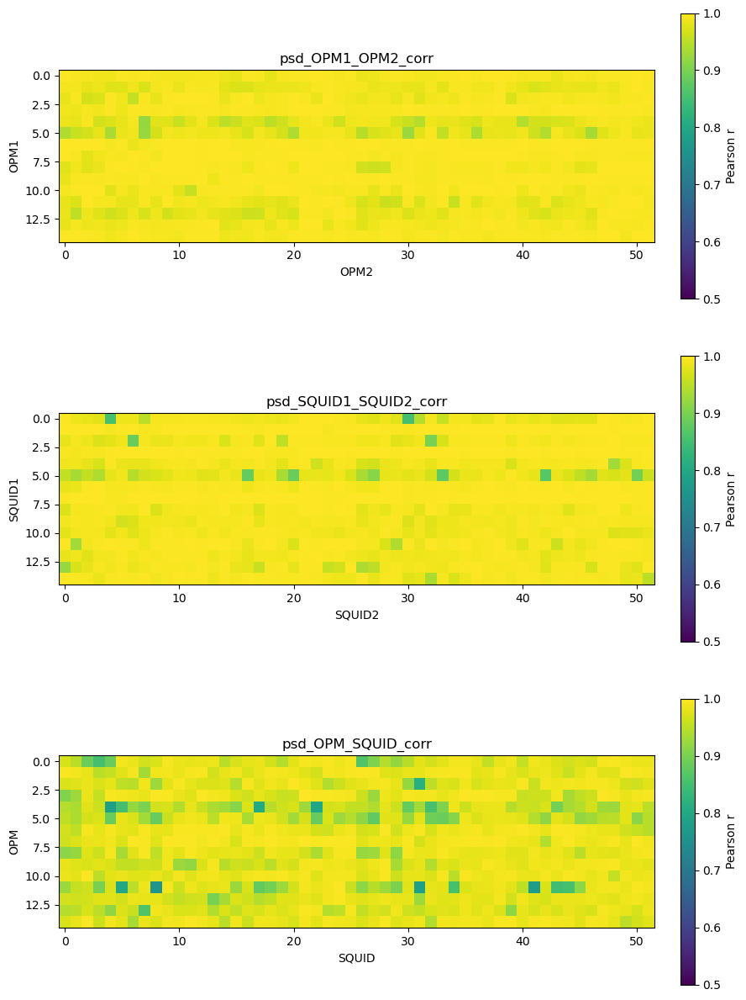

In [10]:
np.shape(OPM_1_psd[0])

same_sub_parcel_corrs_OPM = np.zeros((15,52))
same_sub_parcel_corrs_SQUID = np.zeros((15,52))
same_sub_parcel_corrs_OPM_SQUID = np.zeros((15,52))

for sub in range(15):
    for parcel in range(52):
        OPM1_psd = OPM_1_psd[sub][parcel]
        OPM2_psd = OPM_2_psd[sub][parcel]
        SQUID1_psd = SQUID_1_psd[sub][parcel]
        SQUID2_psd = SQUID_2_psd[sub][parcel]

        same_sub_parcel_corrs_OPM[sub, parcel] = scipy.stats.pearsonr(OPM1_psd, OPM2_psd)[0]
        same_sub_parcel_corrs_SQUID[sub, parcel] = scipy.stats.pearsonr(SQUID1_psd, SQUID2_psd)[0]

        opms1_squids1_corr = scipy.stats.pearsonr(OPM1_psd, SQUID1_psd)[0]
        opms1_squids2_corr = scipy.stats.pearsonr(OPM1_psd, SQUID2_psd)[0]
        opms2_squids1_corr = scipy.stats.pearsonr(OPM2_psd, SQUID1_psd)[0]
        opms2_squids2_corr = scipy.stats.pearsonr(OPM2_psd, SQUID2_psd)[0]

        same_sub_parcel_corrs_OPM_SQUID[sub, parcel] = np.mean((opms1_squids1_corr, opms1_squids2_corr, opms2_squids1_corr, opms2_squids2_corr))    


mats = [same_sub_parcel_corrs_OPM, same_sub_parcel_corrs_SQUID, same_sub_parcel_corrs_OPM_SQUID]  # <- replace with your 3 matrices
titles = ['psd_OPM1_OPM2_corr', 'psd_SQUID1_SQUID2_corr', 'psd_OPM_SQUID_corr']
# y_axis_labels = ['OPM1', 'SQUID1', 'OPM']
# x_axis_labels = ['OPM2', 'SQUID2', 'SQUID']

fig, axes = plt.subplots(3, 1, figsize=(10, 15))#, sharex=True, sharey=True)

for ax, mat, title, x_axis, y_axis in zip(axes, mats, titles, x_axis_labels, y_axis_labels):
    im = ax.imshow(mat, cmap='viridis', vmin=0.5, vmax=1)

    ax.set_title(title)
    ax.set_xlabel(x_axis)
    ax.set_ylabel(y_axis)

    # # mark row-wise maxima
    # n_rows = mat.shape[0]
    # for i in range(n_rows):
    #     j_max = np.argmax(mat[i, :])
    #     ax.scatter(j_max, i, color='yellow', marker='.', s=1, linewidths=2)

    # individual colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Pearson r')

# one shared colorbar
#fig.colorbar(im, ax=axes, label='Pearson r')

#plt.tight_layout()
plt.show()

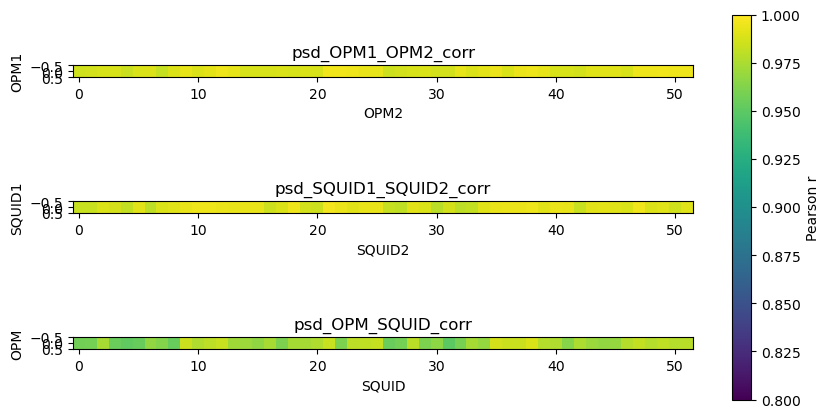

In [11]:
avg_same_sub_parcel_corr_OPM = np.mean(same_sub_parcel_corrs_OPM, axis=0, keepdims=True)
avg_same_sub_parcel_corr_SQUID = np.mean(same_sub_parcel_corrs_SQUID, axis=0, keepdims=True)
avg_same_sub_parcel_corr_OPM_SQUID = np.mean(same_sub_parcel_corrs_OPM_SQUID, axis=0, keepdims=True) 

mats = [avg_same_sub_parcel_corr_OPM, avg_same_sub_parcel_corr_SQUID, avg_same_sub_parcel_corr_OPM_SQUID]  # <- replace with your 3 matrices
titles = ['psd_OPM1_OPM2_corr', 'psd_SQUID1_SQUID2_corr', 'psd_OPM_SQUID_corr']
# y_axis_labels = ['OPM1', 'SQUID1', 'OPM']
# x_axis_labels = ['OPM2', 'SQUID2', 'SQUID']

fig, axes = plt.subplots(3, 1, figsize=(10, 5))#, sharex=True, sharey=True)

for ax, mat, title, x_axis, y_axis in zip(axes, mats, titles, x_axis_labels, y_axis_labels):
    im = ax.imshow(mat, cmap='viridis', vmin=0.8, vmax=1)

    ax.set_title(title)
    ax.set_xlabel(x_axis)
    ax.set_ylabel(y_axis)

    # # mark row-wise maxima
    # n_rows = mat.shape[0]
    # for i in range(n_rows):
    #     j_max = np.argmax(mat[i, :])
    #     ax.scatter(j_max, i, color='yellow', marker='.', s=1, linewidths=2)

    # # individual colorbar
    # cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # cbar.set_label('Pearson r')

# one shared colorbar
fig.colorbar(im, ax=axes, label='Pearson r')

#plt.tight_layout()
plt.show()

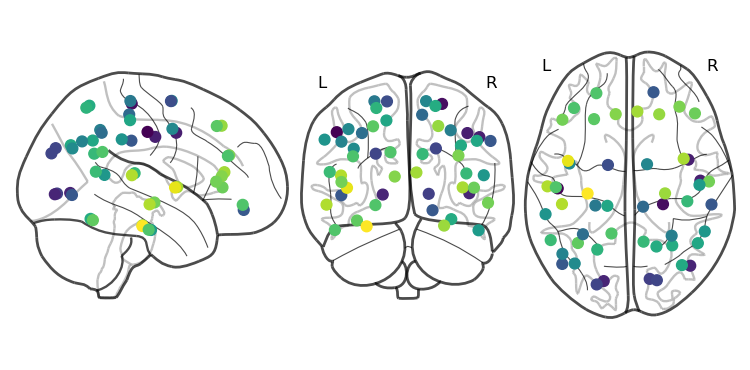

In [12]:
import numpy as np

coords = np.loadtxt("/rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/Info_write_ups/parcel_coords.txt")
values = avg_same_sub_parcel_corr_OPM_SQUID.flatten()

from nilearn import plotting
import numpy as np

values = np.array(values)
coords = np.array(coords)

# fake adjacency matrix (no edges, only nodes)
adjacency = np.zeros((52, 52))

plotting.plot_connectome(
    adjacency_matrix=adjacency,
    node_coords=coords,
    node_color=values,
    node_size=60,
    edge_threshold=0,
    colorbar=False
    # colorbar=True,
    # display_mode="lzry"
)

plotting.show()

Saving images:   0%|          | 0/1 [00:00<?, ?it/s]

([<Figure size 768x480 with 3 Axes>], [[<Axes3D: >, <Axes3D: >]])

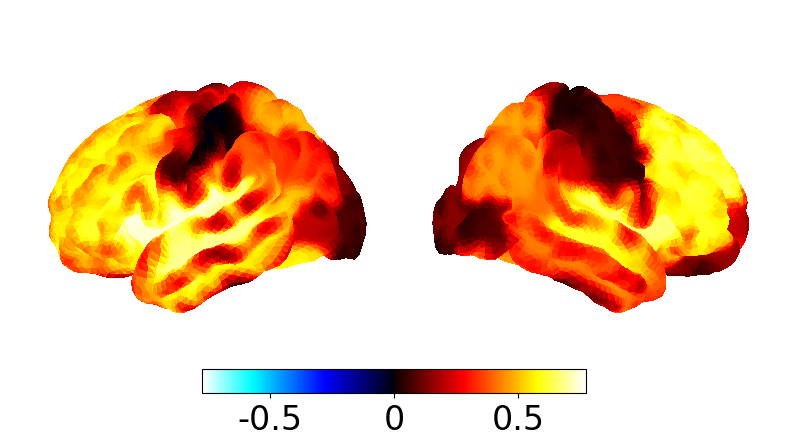

In [14]:
from osl_dynamics.analysis import power
from osl_dynamics.utils import plotting

values = avg_same_sub_parcel_corr_OPM_SQUID.flatten()
values_plot = ((((values - 0.9) / (1.0 - 0.9)) * 2) - 1)  # normalize to [-1, 1] range for better visualization

power.save(
    values_plot,
    mask_file="MNI152_T1_8mm_brain.nii.gz",
    parcellation_file="Glasser52_binary_space-MNI152NLin6_res-8x8x8.nii.gz",
    #filename= f"{figs_dir}/power_maps.png"
)


For voxel grid

/tmp/ipykernel_5285/4107753840.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  same_sub_parcel_corrs_OPM[sub, parcel] = scipy.stats.pearsonr(OPM1_psd, OPM2_psd)[0]
/tmp/ipykernel_5285/4107753840.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  same_sub_parcel_corrs_SQUID[sub, parcel] = scipy.stats.pearsonr(SQUID1_psd, SQUID2_psd)[0]
/tmp/ipykernel_5285/4107753840.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  opms1_squids1_corr = scipy.stats.pearsonr(OPM1_psd, SQUID1_psd)[0]
/tmp/ipykernel_5285/4107753840.py:21: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  opms1_squids2_corr = scipy.stats.pearsonr(OPM1_psd, SQUID2_psd)[0]
/tmp/ipykernel_5285/4107753840.py:22: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  opms2_squids1_corr =

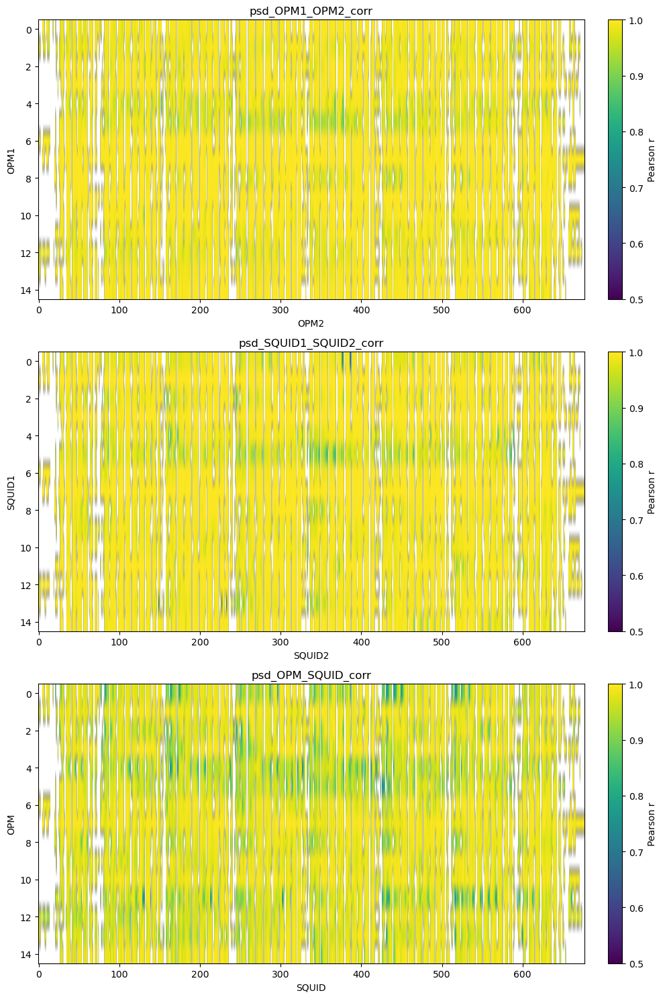

In [12]:
OPM_1_psd = np.array(psds_list_cut_opm_beam[::2])#[:,350:351,:] #psds_av_opm[::2] #psds_list_cut_opm[::2]
OPM_2_psd = np.array(psds_list_cut_opm_beam[1::2])#[:,350:351,:] 
SQUID_1_psd = np.array(psds_list_cut_squid_beam[::2])#[:,350:351,:] 
SQUID_2_psd = np.array(psds_list_cut_squid_beam[1::2])#[:,350:351,:] 

same_sub_parcel_corrs_OPM = np.zeros((15,677))
same_sub_parcel_corrs_SQUID = np.zeros((15,677))
same_sub_parcel_corrs_OPM_SQUID = np.zeros((15,677))

for sub in range(15):
    for parcel in range(677):
        OPM1_psd = OPM_1_psd[sub][parcel]
        OPM2_psd = OPM_2_psd[sub][parcel]
        SQUID1_psd = SQUID_1_psd[sub][parcel]
        SQUID2_psd = SQUID_2_psd[sub][parcel]

        same_sub_parcel_corrs_OPM[sub, parcel] = scipy.stats.pearsonr(OPM1_psd, OPM2_psd)[0]
        same_sub_parcel_corrs_SQUID[sub, parcel] = scipy.stats.pearsonr(SQUID1_psd, SQUID2_psd)[0]

        opms1_squids1_corr = scipy.stats.pearsonr(OPM1_psd, SQUID1_psd)[0]
        opms1_squids2_corr = scipy.stats.pearsonr(OPM1_psd, SQUID2_psd)[0]
        opms2_squids1_corr = scipy.stats.pearsonr(OPM2_psd, SQUID1_psd)[0]
        opms2_squids2_corr = scipy.stats.pearsonr(OPM2_psd, SQUID2_psd)[0]

        same_sub_parcel_corrs_OPM_SQUID[sub, parcel] = np.mean((opms1_squids1_corr, opms1_squids2_corr, opms2_squids1_corr, opms2_squids2_corr))    


mats = [same_sub_parcel_corrs_OPM, same_sub_parcel_corrs_SQUID, same_sub_parcel_corrs_OPM_SQUID]  # <- replace with your 3 matrices
titles = ['psd_OPM1_OPM2_corr', 'psd_SQUID1_SQUID2_corr', 'psd_OPM_SQUID_corr']
y_axis_labels = ['OPM1', 'SQUID1', 'OPM']
x_axis_labels = ['OPM2', 'SQUID2', 'SQUID']

fig, axes = plt.subplots(3, 1, figsize=(10, 15))#, sharex=True, sharey=True)

for ax, mat, title, x_axis, y_axis in zip(axes, mats, titles, x_axis_labels, y_axis_labels):
    im = ax.imshow(mat, cmap='viridis', vmin=0.5, vmax=1, aspect='auto')

    ax.set_title(title)
    ax.set_xlabel(x_axis)
    ax.set_ylabel(y_axis)

    # # mark row-wise maxima
    # n_rows = mat.shape[0]
    # for i in range(n_rows):
    #     j_max = np.argmax(mat[i, :])
    #     ax.scatter(j_max, i, color='yellow', marker='.', s=1, linewidths=2)

    # individual colorbar
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Pearson r')

# one shared colorbar
#fig.colorbar(im, ax=axes, label='Pearson r')

plt.tight_layout()
plt.show()

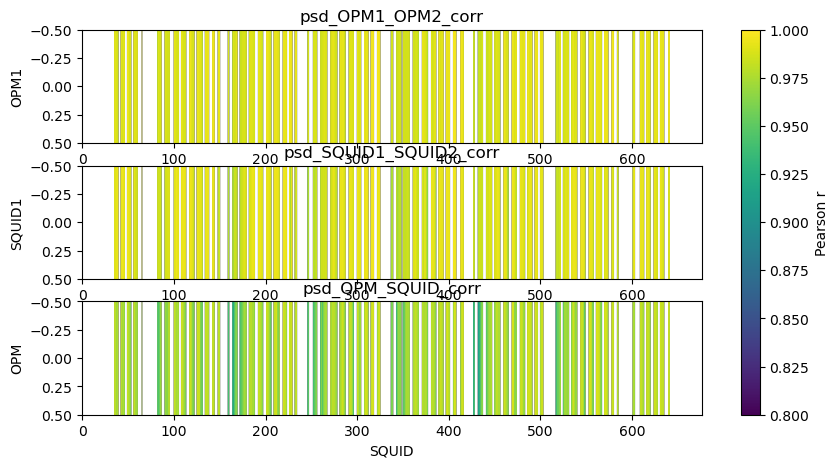

In [45]:
avg_same_sub_parcel_corr_OPM = np.mean(same_sub_parcel_corrs_OPM, axis=0, keepdims=True)
avg_same_sub_parcel_corr_SQUID = np.mean(same_sub_parcel_corrs_SQUID, axis=0, keepdims=True)
avg_same_sub_parcel_corr_OPM_SQUID = np.mean(same_sub_parcel_corrs_OPM_SQUID, axis=0, keepdims=True) 

mats = [avg_same_sub_parcel_corr_OPM, avg_same_sub_parcel_corr_SQUID, avg_same_sub_parcel_corr_OPM_SQUID]  # <- replace with your 3 matrices
titles = ['psd_OPM1_OPM2_corr', 'psd_SQUID1_SQUID2_corr', 'psd_OPM_SQUID_corr']
# y_axis_labels = ['OPM1', 'SQUID1', 'OPM']
# x_axis_labels = ['OPM2', 'SQUID2', 'SQUID']

fig, axes = plt.subplots(3, 1, figsize=(10, 5))#, sharex=True, sharey=True)

for ax, mat, title, x_axis, y_axis in zip(axes, mats, titles, x_axis_labels, y_axis_labels):
    im = ax.imshow(mat, cmap='viridis', vmin=0.8, vmax=1, aspect='auto')

    ax.set_title(title)
    ax.set_xlabel(x_axis)
    ax.set_ylabel(y_axis)

    # # mark row-wise maxima
    # n_rows = mat.shape[0]
    # for i in range(n_rows):
    #     j_max = np.argmax(mat[i, :])
    #     ax.scatter(j_max, i, color='yellow', marker='.', s=1, linewidths=2)

    # # individual colorbar
    # cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # cbar.set_label('Pearson r')

# one shared colorbar
fig.colorbar(im, ax=axes, label='Pearson r')

#plt.tight_layout()
plt.show()

In [ ]:
def gettingcoords(beam_fif):

    raw = mne.io.read_raw_fif(beam_fif)

    fs = raw.info["sfreq"]
    parc_ts = raw.get_data(picks="misc", reject_by_annotation="omit")

    f, psd = scipy.signal.welch(parc_ts, fs=fs, nperseg=fs, nfft=fs * 2)

    return f, psd



In [14]:
base = "/rdrives/DRS-foundation-brain/zoe_data/BIDS"
deriv = f"{base}/derivatives_anna_01042026"
beam_fif_opm = (f"{deriv}/beamformed/sub-001_ses-001_task-braille_run-001_beamformed_raw.fif")
rawbeam = mne.io.read_raw_fif(beam_fif_opm, preload=True)
voxel_coords_1 = np.array([ch['loc'][:3] for ch in rawbeam.info['chs']])

Opening raw data file /rdrives/DRS-foundation-brain/zoe_data/BIDS/derivatives_anna_01042026/beamformed/sub-001_ses-001_task-braille_run-001_beamformed_raw.fif...
Isotrak not found
    Range : 0 ... 326768 =      0.000 ...  1307.072 secs
Ready.
Reading 0 ... 326768  =      0.000 ...  1307.072 secs...


In [19]:
voxel_coords_mm = voxel_coords_1 * 1000


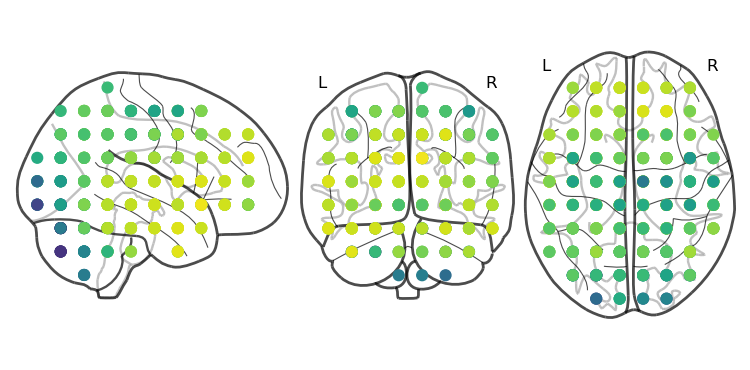

In [39]:
import numpy as np

coords = voxel_coords_mm
values = avg_same_sub_parcel_corr_OPM_SQUID.flatten()

from nilearn import plotting
import numpy as np

values = np.array(values)
coords = np.array(coords)

# fake adjacency matrix (no edges, only nodes)
adjacency = np.zeros((677, 677))

plotting.plot_connectome(
    adjacency_matrix=adjacency,
    node_coords=coords,
    node_color=values,
    node_size=60,
    edge_threshold=0,
    colorbar=False
    # colorbar=True,
    # display_mode="lzry"
)

plotting.show()

In [47]:
import numpy as np
import plotly.graph_objects as go

coords = voxel_coords_mm
values = avg_same_sub_parcel_corr_SQUID.flatten()

# Create mask for valid (non-NaN) values
mask = ~np.isnan(values)

coords_clean = coords[mask]
values_clean = values[mask]

fig = go.Figure(data=go.Scatter3d(
    x=coords_clean[:,0],
    y=coords_clean[:,1],
    z=coords_clean[:,2],
    mode='markers',
    marker=dict(
        size=5,
        color=values_clean,
        colorscale='viridis',
        colorbar=dict(title='Correlation'),
        cmin=0.8,
        cmax=1
    )
))

fig.show()